This experiment is dedicated to test $\hat R_{\nu}$ on different multivariate normal distribution with diagonal covariance, but the variance for each dimension varies.

In [ ]:
!pip uninstall -yq jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt tensorflow-probability
# heads out since jax might drop support for cuda 12, currently (as of Aug 10, 2026), JAX has issues with CUDA 13
# see this post: https://github.com/jax-ml/jax/issues/37923
!pip install -Uq "jax[cuda12]" tfp-nightly blackjax inference_gym optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.2/188.2 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 MB 29.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow-probability>=0.13.0, which is not installed.


**Package Import and other setups**

In [ ]:
# GPU set up to accelerate performance
import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, jit, vmap, lax
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
import inference_gym.using_jax as gym
import jaxlib
import blackjax

import optax

# import arviz as az
# import arviz_stats as avs

import warnings
warnings.filterwarnings('ignore')

import psutil

import gc

from google.colab import drive
from matplotlib.lines import Line2D

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

# verification to make sure this is on a GPU
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0)]
gpu


In [ ]:
drive.mount('/content/drive')
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/BJX_Utility.py'
with open(utility_link) as f: exec(f.read())
plot_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/D100_Utility.py'
with open(plot_link) as f: exec(f.read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Hyperparam Setups**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

**Experiment Part**

First Distribution with diagonal covariance matrix where $\sigma^2_d$ differ from dimensions.

In [ ]:
num_dim = 100
# mean array:
mu = jnp.full(num_dim, 0.0)
# covariance matrix:
# just my design:
# Variances for dimensions 1, 11, 21, ..., 91
# are 1000; dimensions 5, 15, ..., 95 are 100;
# all other dimensions have variance 1.
variances = jnp.array([
    1000.0 if (i % 10 == 0)
    else 100.0 if (i % 10 == 4)
    else 1.0
    for i in range(num_dim)
])

# Diagonal covariance matrix
cov = jnp.diag(variances)

target = tfd.MultivariateNormalFullCovariance(
      loc=jnp.array(mu),
      covariance_matrix=cov)
init_step_size = 0.5
def target_log_prob_fn(x):
    return target.log_prob(x)
def initialize(shape, key):
    return random.normal(key, shape + (num_dim,))

mean_benchmark = target.mean()
var_benchmark = target.variance()

In [ ]:
#simulation part:
OneFive_MSE_c_list = []
OneFive_MSE_n_list = []
OneFive_RHat_c_list = []
OneFive_RHat_n_list = []

In [ ]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)
for length in warmup_length:
  mem(f"Simulation Start")
  simulation(length,num_chains_short, num_super_chains,
             False,initialize, keys,
             target_log_prob_fn,init_step_size,
             repitition, OneFive_RHat_c_list,OneFive_MSE_c_list,
             mean_benchmark,var_benchmark)
  simulation(length,num_chains_short, num_super_chains,
             True,initialize, keys,
             target_log_prob_fn,init_step_size,
             repitition, OneFive_RHat_n_list,OneFive_MSE_n_list,
             mean_benchmark,var_benchmark)

Simulation Start: 1697.1 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.0004926114343106747
Naive initialization. Warmup Length: 10; mean of MSE is: 0.000442588614532724
Simulation Start: 1951.6 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.0004609787429217249
Naive initialization. Warmup Length: 20; mean of MSE is: 0.00040520750917494297
Simulation Start: 1980.5 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.00046835970715619624
Naive initialization. Warmup Length: 30; mean of MSE is: 0.00041856494499370456
Simulation Start: 1996.7 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.0004493079031817615
Naive initialization. Warmup Length: 40; mean of MSE is: 0.0004281039291527122
Simulation Start: 2013.6 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.0004500682116486132
Naive initialization. Warmup Length: 50; mean of MSE is: 0.00043902816832996905
Simulation Start: 2037.9 MB
Constrain

**Save to dataframe and file**

In [ ]:
MSE_c_df = pd.DataFrame(OneFive_MSE_c_list)
R_Hat_c_df = pd.DataFrame(OneFive_RHat_c_list)

MSE_n_df = pd.DataFrame(OneFive_MSE_n_list)
R_Hat_n_df = pd.DataFrame(OneFive_RHat_n_list)

In [ ]:
MSE_c_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_MSE_c.pkl"
)

MSE_n_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_MSE_n.pkl"
)

R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_Rhat_c.pkl"
)

R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/D100_1000_500_Rhat_n.pkl"
)

### More tests

To exclude the possibility of getting lucky, we randomly assign dimensions to have high variance:

In [ ]:
num_dim = 100

# Mean array
mu = jnp.full(num_dim, 0.0)

# Randomly select dimensions for large variances
key = random.PRNGKey(42)

key, subkey = random.split(key)
selected_1000 = random.choice(
    subkey,
    num_dim,
    shape=(10,),
    replace=False
)

key, subkey = random.split(key)
remaining_dims = jnp.setdiff1d(
    jnp.arange(num_dim),
    selected_1000
)
selected_100 = random.choice(
    subkey,
    remaining_dims,
    shape=(10,),
    replace=False
)

# Variance = 5 for all dimensions initially
variances = jnp.full(num_dim, 5.0)

# Assign randomly selected dimensions
variances = variances.at[selected_1000].set(1000.0)
variances = variances.at[selected_100].set(100.0)

# Diagonal covariance matrix
cov = jnp.diag(variances)

target = tfd.MultivariateNormalFullCovariance(
    loc=jnp.array(mu),
    covariance_matrix=cov
)

init_step_size = 0.5

def target_log_prob_fn(x):
    return target.log_prob(x)

def initialize(shape, key):
    return random.normal(key, shape + (num_dim,))

mean_benchmark = target.mean()
var_benchmark = target.variance()

In [ ]:
#simulation part:
Weird_MSE_c_list = []
Weird_MSE_n_list = []
Weird_RHat_c_list = []
Weird_RHat_n_list = []

In [ ]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)
for length in warmup_length:
  mem(f"Simulation Start")
  simulation(length,num_chains_short, num_super_chains,
             False,initialize, keys,
             target_log_prob_fn,init_step_size,
             repitition, Weird_RHat_c_list,Weird_MSE_c_list,
             mean_benchmark,var_benchmark)
  simulation(length,num_chains_short, num_super_chains,
             True,initialize, keys,
             target_log_prob_fn,init_step_size,
             repitition, Weird_RHat_n_list,Weird_MSE_n_list,
             mean_benchmark,var_benchmark)

Simulation Start: 1735.7 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.0004486328107304871
Naive initialization. Warmup Length: 10; mean of MSE is: 0.0004178773087915033
Simulation Start: 1982.7 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.00044245264143683016
Naive initialization. Warmup Length: 20; mean of MSE is: 0.00041955773485824466
Simulation Start: 1988.5 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.00046229822328314185
Naive initialization. Warmup Length: 30; mean of MSE is: 0.0004461873904801905
Simulation Start: 2004.7 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.00045431219041347504
Naive initialization. Warmup Length: 40; mean of MSE is: 0.00044096511555835605
Simulation Start: 2021.6 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.00047067017294466496
Naive initialization. Warmup Length: 50; mean of MSE is: 0.00046282439143396914
Simulation Start: 2045.4 MB
Const

**Save to Dataframe and File**

In [ ]:
MSE_c_df = pd.DataFrame(Weird_MSE_c_list)
R_Hat_c_df = pd.DataFrame(Weird_RHat_c_list)

MSE_n_df = pd.DataFrame(Weird_MSE_n_list)
R_Hat_n_df = pd.DataFrame(Weird_RHat_n_list)

In [ ]:
MSE_c_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Weird_MSE_c.pkl"
)

MSE_n_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Weird_MSE_n.pkl"
)

R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Weird_Rhat_c.pkl"
)

R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Weird_Rhat_n.pkl"
)

In [ ]:
HighlightIndex = (
    selected_100.tolist()
    + selected_1000.tolist()
)

Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]

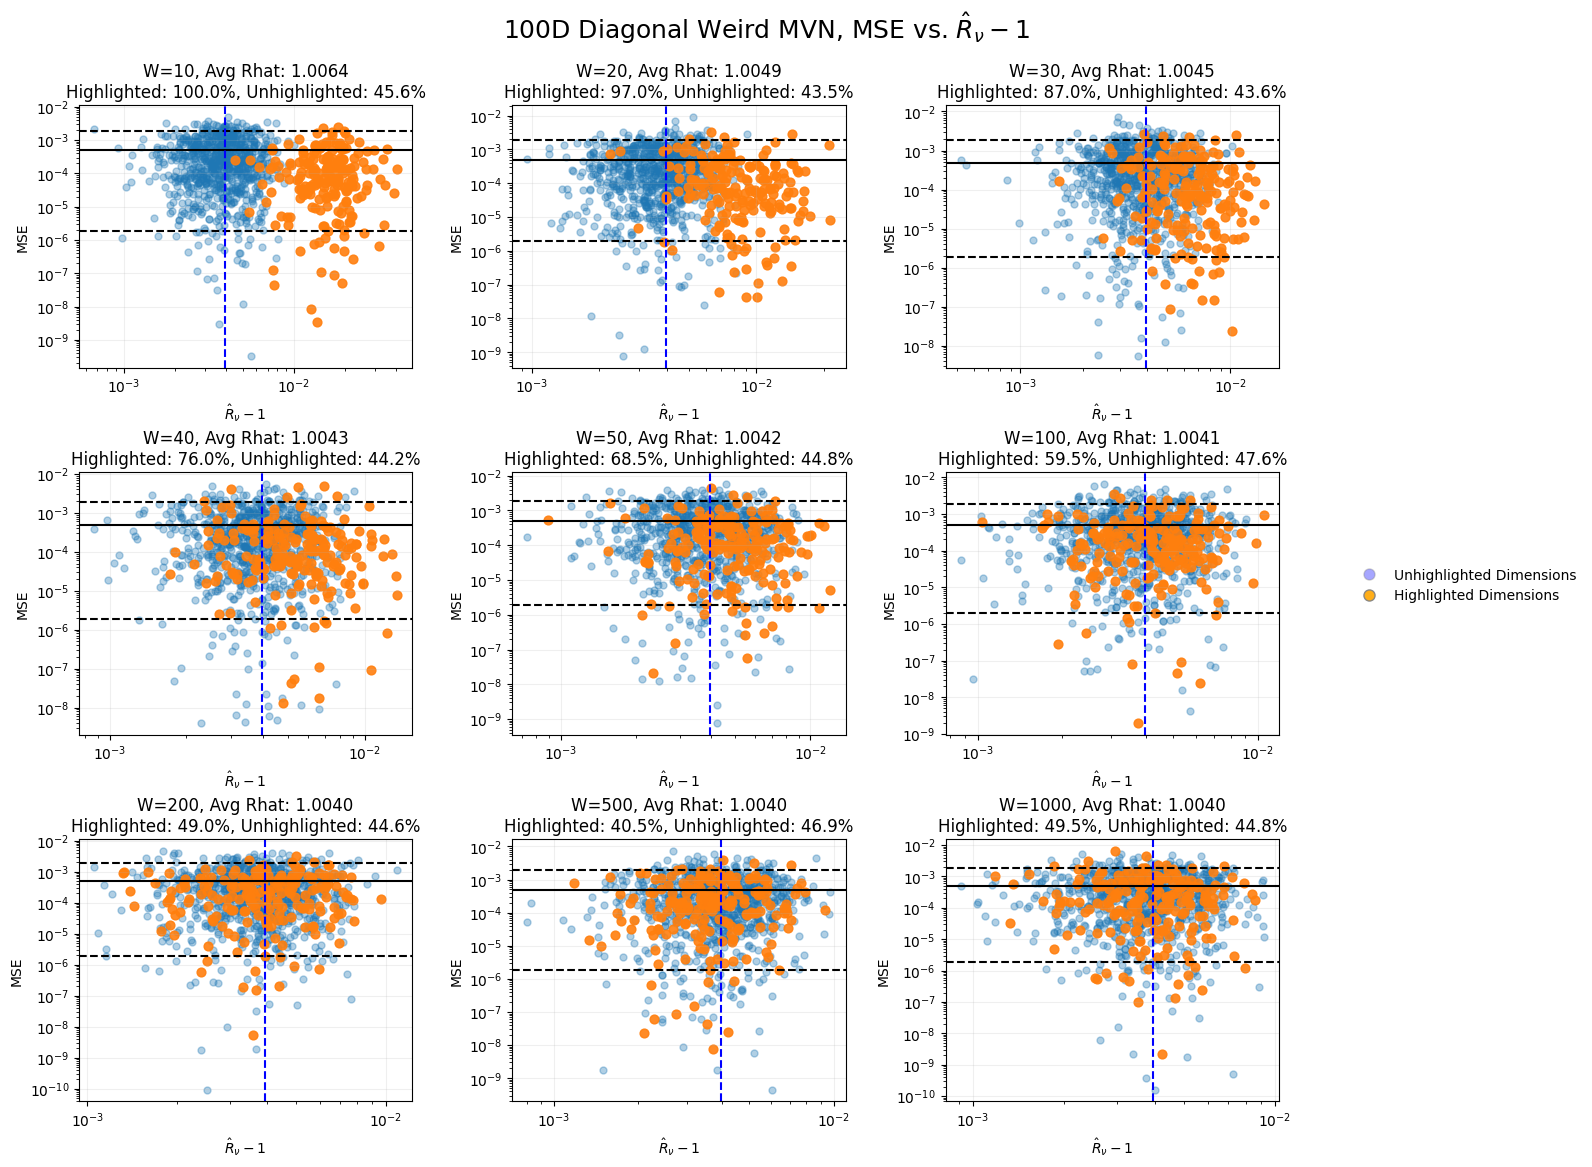

In [ ]:
plot_mse_vs_rhat_9("100D Diagonal Weird MVN",
    R_Hat_c_df,
    Warmup_List,
    HighlightIndex,
    bound,
    threshold,
    num_chains_short)